<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Implementaci%C3%B3n_de_una_RNN_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Implementación de una RNN-Armando Chacón Terrazas**

Basados en el ejemplo de implementación de una red neuronal recurrente compartido en el archivo Ejemplo RNN imdb, realice los siguientes experimentos:

Replique los resultados obtenidos.
Modifique la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros. Solo cambie la línea "layers.SimpleRNN(64)" por "layers.LSTM(64)" .
A continuación, cambie la red LSTM por una GRU. Solo cambie la línea "layers.LSTM(64)" por  "layers.GRU(64)" .
Registre el desempeño de las redes con el conjunto de prueba y presente las curvas de entrenamiento: Accuracy vs. epochs y Loss vs. epochs, de los conjuntos de entrenamiento y validación.

Registre el tiempo de entrenamiento por época que tomaron en promedio cada una de las redes.

## **1. IMPORTAR LAS HERRAMIENTAS (LIBRERÍAS)**

En esta primera celda cargaremos las librerías necesarias y la base de datos de IMDB limitando el vocabulario a las 10,000 palabras más frecuentes. Además, estandarizaremos todas las reseñas para que tengan exactamente 200 palabras de longitud.

In [1]:
# Importamos las librerías necesarias
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Configuración inicial
VOCAB_SIZE = 10000
MAX_LEN = 200

print("Cargando los datos de IMDB...")
# Descargamos la base de datos y la dividimos
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Ajustamos (padding/truncamiento) para que todas las secuencias midan 200
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Datos de entrenamiento listos: {x_train.shape}")
print(f"Datos de prueba listos: {x_test.shape}")

Cargando los datos de IMDB...
Datos de entrenamiento listos: (25000, 200)
Datos de prueba listos: (25000, 200)


# **2. Función para construir la arquitectura de la red**

Aquí definimos una función que nos permite crear la red neuronal. Dependiendo del texto que le pasemos, construirá una capa SimpleRNN, LSTM o GRU con 64 unidades , terminando siempre en una neurona con activación sigmoide para la clasificación binaria.

In [2]:
def construir_modelo(tipo_rnn):
    modelo = keras.Sequential()

    # Capa de entrada
    modelo.add(keras.layers.Input(shape=(MAX_LEN,), dtype='int32'))

    # Capa de Embedding para contextualizar los datos
    modelo.add(keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128))

    # Selección dinámica de la capa recurrente
    if tipo_rnn == "SimpleRNN":
        modelo.add(layers.SimpleRNN(64))
    elif tipo_rnn == "LSTM":
        modelo.add(layers.LSTM(64))
    elif tipo_rnn == "GRU":
        modelo.add(layers.GRU(64))

    # Capa de salida para clasificación binaria
    modelo.add(layers.Dense(1, activation="sigmoid"))

    # Compilación del modelo
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return modelo

# **3. Herramienta personalizada para medir el tiempo**

Esta celda crea una clase pequeña que funcionará como un cronómetro interno para registrar el tiempo que toma procesar cada época.

In [3]:
class MedidorDeTiempo(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.tiempos_epocas = []

    def on_epoch_begin(self, epoch, logs=None):
        self.inicio_epoca = time.time()

    def on_epoch_end(self, epoch, logs=None):
        tiempo_total = time.time() - self.inicio_epoca
        self.tiempos_epocas.append(tiempo_total)

# **4. Ciclo de entrenamiento y evaluación**

Aquí iteramos sobre los tres tipos de redes, entrenándolas por un máximo de 10 épocas usando lotes de 64 datos  y guardando los resultados. También incluye el monitor de parada temprana (Early Stopping) con una paciencia de 5 épocas.

In [4]:
# Configuración del entrenamiento
epocas = 10
tamaño_lote = 64
modelos_a_probar = ["SimpleRNN", "LSTM", "GRU"]
resultados = {}

for tipo in modelos_a_probar:
    print(f"\n{'='*50}")
    print(f"Entrenando modelo: {tipo}")
    print(f"{'='*50}")

    modelo = construir_modelo(tipo)

    # Detiene el entrenamiento si no hay mejora en validación tras 5 épocas
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
    medidor_tiempo = MedidorDeTiempo()

    # Proceso de entrenamiento usando 15% de datos para validación
    historial = modelo.fit(
        x_train, y_train,
        validation_split=0.15,
        epochs=epocas,
        batch_size=tamaño_lote,
        callbacks=[early_stopping, medidor_tiempo],
        verbose=1
    )

    # Evaluación final con el conjunto de prueba
    loss_prueba, exactitud_prueba = modelo.evaluate(x_test, y_test, verbose=0)
    tiempo_promedio = np.mean(medidor_tiempo.tiempos_epocas)

    # Almacenamiento de métricas
    resultados[tipo] = {
        'historial': historial.history,
        'exactitud': exactitud_prueba,
        'tiempo_promedio': tiempo_promedio
    }


Entrenando modelo: SimpleRNN
Epoch 1/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.5995 - loss: 0.6574 - val_accuracy: 0.7672 - val_loss: 0.4877
Epoch 2/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.7679 - loss: 0.4863 - val_accuracy: 0.7859 - val_loss: 0.4610
Epoch 3/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.8756 - loss: 0.2992 - val_accuracy: 0.8008 - val_loss: 0.4511
Epoch 4/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.9311 - loss: 0.1900 - val_accuracy: 0.7811 - val_loss: 0.4959
Epoch 5/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9596 - loss: 0.1194 - val_accuracy: 0.8141 - val_loss: 0.5452
Epoch 6/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9853 - loss: 0.0498 - val_accuracy: 0.8008 - val_loss: 0.7026
Epoch 7/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.9900 - loss: 0.0327 - val_accuracy: 0.7680 - val_loss: 0.8585
Epoch 8/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accu

# **5. Impresión de tabla y gráficas**

Una vez que el entrenamiento de las tres redes haya terminado, para visualizar el resumen de desempeño y las curvas comparativas de Accuracy y Loss.


RESUMEN DE DESEMPEÑO: SimpleRNN vs LSTM vs GRU
Modelo          | Exactitud (Test)     | Tiempo Promedio/Época
------------------------------------------------------------
SimpleRNN       |              80.60% |            33.71 seg
LSTM            |              86.41% |            93.20 seg
GRU             |              86.70% |           100.50 seg


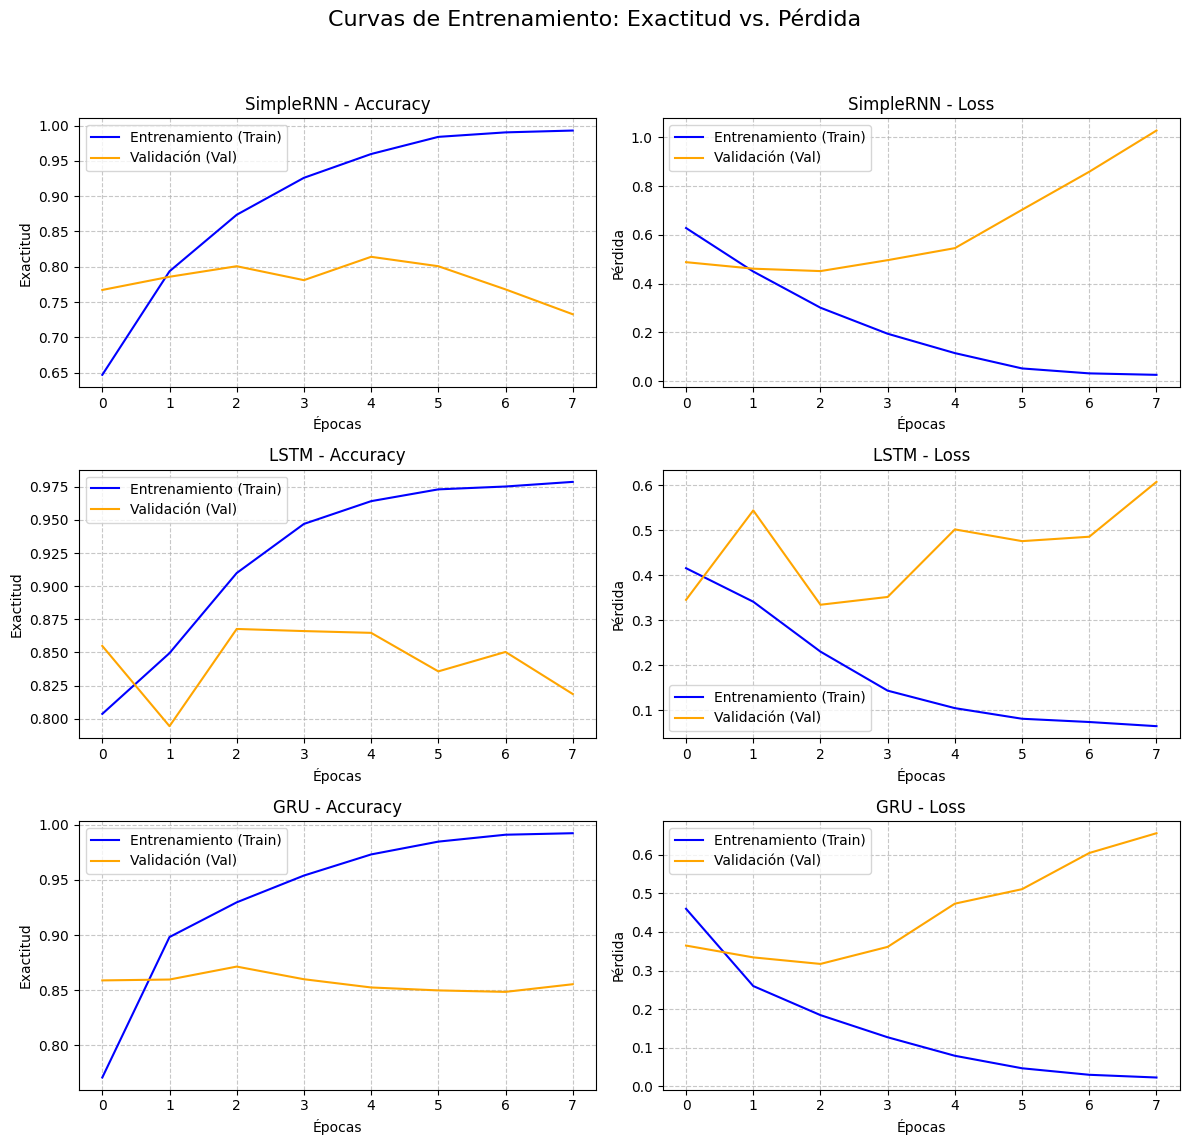

In [5]:
# 1. Tabla de resumen
print("\n" + "="*60)
print("RESUMEN DE DESEMPEÑO: SimpleRNN vs LSTM vs GRU")
print("="*60)
print(f"{'Modelo':<15} | {'Exactitud (Test)':<20} | {'Tiempo Promedio/Época':<20}")
print("-" * 60)
for tipo, datos in resultados.items():
    print(f"{tipo:<15} | {datos['exactitud']*100:>18.2f}% | {datos['tiempo_promedio']:>16.2f} seg")

# 2. Generación de gráficas
fig, axes = plt.subplots(len(modelos_a_probar), 2, figsize=(12, 12))
fig.suptitle('Curvas de Entrenamiento: Exactitud vs. Pérdida', fontsize=16)

for i, tipo in enumerate(modelos_a_probar):
    hist = resultados[tipo]['historial']

    # Gráfica de Exactitud (Accuracy)
    axes[i, 0].plot(hist["accuracy"], label="Entrenamiento (Train)", color="blue")
    axes[i, 0].plot(hist["val_accuracy"], label="Validación (Val)", color="orange")
    axes[i, 0].set_title(f"{tipo} - Accuracy")
    axes[i, 0].set_xlabel("Épocas")
    axes[i, 0].set_ylabel("Exactitud")
    axes[i, 0].grid(True, linestyle='--', alpha=0.7)
    axes[i, 0].legend()

    # Gráfica de Pérdida (Loss)
    axes[i, 1].plot(hist["loss"], label="Entrenamiento (Train)", color="blue")
    axes[i, 1].plot(hist["val_loss"], label="Validación (Val)", color="orange")
    axes[i, 1].set_title(f"{tipo} - Loss")
    axes[i, 1].set_xlabel("Épocas")
    axes[i, 1].set_ylabel("Pérdida")
    axes[i, 1].grid(True, linestyle='--', alpha=0.7)
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()